<a href="https://colab.research.google.com/github/alexkimoni/ppl-lab-4-2-build-a-code-generating-ai-bot/blob/main/Code_Generating_AI_Bot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.5 MB/s eta 0:00:00


In [69]:
import os
from groq import Groq
client = Groq(api_key="API KEY")


In [72]:
def generate_code(prompt):
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": f"Generate code for: {prompt}"}]
    )
    return response.choices[0].message.content.strip()

In [73]:
# prompt 1
prompt = "Write a Python function to check if a number is prime."
generated_code_1 = generate_code(prompt)
print(generated_code_1)

**Prime Number Checker Function**

Below is a Python function that checks if a given number is prime.

```python
def is_prime(n):
    """
    Checks if a number is prime.

    Args:
        n (int): The number to check.

    Returns:
        bool: True if the number is prime, False otherwise.
    """
    if n <= 1:
        return False
    for i in range(2, int(n ** 0.5) + 1):
        if n % i == 0:
            return False
    return True

# Example usage:
def main():
    numbers_to_check = [2, 3, 4, 5, 6, 23, 37, 48, 59]
    for num in numbers_to_check:
        print(f"Is {num} a prime number? {is_prime(num)}")

if __name__ == "__main__":
    main()
```

**How it works:**

1. The function takes an integer `n` as input.
2. If `n` is less than or equal to 1, it's not prime, so we return `False`.
3. We only need to check divisibility up to the square root of `n`, as any factor larger than that would have a corresponding factor smaller than the square root.
4. We loop through numbers fro

In [74]:
# prompt 2
prompt = "Write a powershell function to check network traffic"
generated_code_2 = generate_code(prompt)
print(generated_code_2)

**Get-NetworkTraffic.ps1**
```powershell
# PowerShell function to retrieve network traffic statistics

function Get-NetworkTraffic {
    <#
    .SYNOPSIS
    Retrieves network traffic statistics for the local machine.

    .DESCRIPTION
    This function uses the Get-NetTCPConnection and Get-NetUDPEndpoint cmdlets to retrieve network traffic statistics.

    .EXAMPLE
    Get-NetworkTraffic
    #>

    # Get all TCP connections
    $tcpConnections = Get-NetTCPConnection

    # Get all UDP endpoints
    $udpEndpoints = Get-NetUDPEndpoint

    # Create a custom object to hold the results
    $results = [PSCustomObject]@{
        TotalTCPConnections = $tcpConnections.Count
        TotalUDPEndpoints   = $udpEndpoints.Count
        TCPConnections      = $tcpConnections
        UDPEndpoints        = $udpEndpoints
    }

    # Return the results
    $results
}

# Example usage
Get-NetworkTraffic | Format-List
```

**Usage**

1. Save the above code in a file named `Get-NetworkTraffic.ps1`.
2. Op

In [79]:
# prompt 3
prompt = "Write a c++ function to check running processes"
generated_code_3 = generate_code(prompt)
print(generated_code_3)

**Process Checker Function in C++**

Below is an example of a C++ function that checks running processes on a Unix-based system (e.g., Linux or macOS). This function uses the `opendir`, `readdir`, and `popen` functions from the C standard library.

```cpp
#include <iostream>
#include <fstream>
#include <dirent.h>
#include <unistd.h>
#include <sys/stat.h>

// Function to check running processes
void checkRunningProcesses() {
    // Open the /proc directory, which contains information about running processes
    DIR* procDir = opendir("/proc");
    if (procDir == NULL) {
        std::cerr << "Error: Unable to open /proc directory" << std::endl;
        return;
    }

    // Iterate over the contents of the /proc directory
    dirent* entry;
    while ((entry = readdir(procDir)) != NULL) {
        // Check if the current entry is a directory (representing a process)
        if (entry->d_type == DT_DIR) {
            // Try to convert the entry name to an integer (process ID)
            i

In [76]:
# prompt 4
prompt = "Write a decorator in scala that times a function"
generated_code_4 = generate_code(prompt)
print(generated_code_4)

### Timing Decorator in Scala
Here's a simple implementation of a timing decorator in Scala. This decorator uses the `java.time` package to measure the execution time of a function.

```scala
import java.time.{Instant, Duration}

object TimingDecorator {
  def time[R](f: => R): R = {
    val startTime = Instant.now()
    val result = f
    val endTime = Instant.now()
    val executionTime = Duration.between(startTime, endTime).toMillis
    println(s"Execution time: ${executionTime}ms")
    result
  }
}

object Main {
  def main(args: Array[String]): Unit = {
    def myFunction(): Unit = {
      // Simulating some work
      Thread.sleep(1000)
      println("Function executed")
    }

    TimingDecorator.time(myFunction())
  }
}
```

In this example, the `time` function takes a call-by-name parameter `f` of type `R` and returns the result of `f`. It records the current time before and after executing `f`, calculates the execution time, and prints it out.

However, if you want a more reu

In [90]:
# prompt 5
prompt = "Write a c function that check cpu teampreture"
generated_code_5 = generate_code(prompt)
print(generated_code_5)

To write a C function that checks the CPU temperature, you would typically need to access system-specific files or use system API calls that provide this information. Unfortunately, there's no standard, portable way to do this in C that works across all operating systems. However, I can show you an example for Linux systems, which involves reading the temperature from files in the `/sys` filesystem.

For Linux systems, the CPU temperature is often available in the `/sys/class/thermal` directory or through specific paths like `/sys/class/hwmon/hwmon0/temp1_input` for some systems. The path can vary based on the system's configuration and hardware.

Here is a basic example of how you might write such a function. This example assumes that the temperature is available at `/sys/class/thermal/thermal_zone0/temp`. You might need to adjust the file path based on your system's configuration.

```c
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <fcntl.h>
#include <unistd.h>


In [94]:
def explain_code(code):
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": f"Explain what the following Python code does:\n\n{code}"}]
    )
    return response.choices[0].message.content.strip()

In [95]:
explanation = explain_code(generated_code_5)
print("Explanation:\n")
print(explanation)

Explanation:

The provided code is actually written in C, not Python. It's a C program designed to read and display the CPU temperature on a Linux system. 

Here's a breakdown of what the code does:

1. **Includes necessary libraries**: The code starts by including the necessary C libraries for input/output (`stdio.h`), standard library (`stdlib.h`), string operations (`string.h`), file control (`fcntl.h`), and Unix standard functions (`unistd.h`).

2. **Defines a function to get CPU temperature**: The `get_cpu_temperature` function is defined to retrieve the CPU temperature. It opens the file `/sys/class/thermal/thermal_zone0/temp`, reads the temperature value from it, closes the file, and then converts the temperature from thousandths of a degree Celsius to degrees Celsius.

3. **Main function**: In the `main` function, the program calls `get_cpu_temperature` to get the current CPU temperature and prints it to the console. If the temperature retrieval is successful, it displays the t

In [96]:
def refactor_code(code):
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": f"Refactor and improve the following Python code:\n\n{code}"}]
    )
    return response.choices[0].message.content.strip()

In [97]:
refactored = refactor_code(generated_code_5)
print("Refactored code:\n")
print(refactored)

Refactored code:

### Refactored Python Code

The given C code can be refactored and improved using Python for better readability and maintainability. We will use the `psutil` library to get the CPU temperature, which provides an interface for retrieving information on running processes and system utilization.

```python
import psutil

def get_cpu_temperature() -> float:
    """
    Function to check CPU temperature.
    
    Returns:
        float: The CPU temperature in degrees Celsius.
    """
    try:
        # Get the CPU temperature
        temperature = psutil.sensors_temperatures()
        
        if temperature:
            # Check if there's at least one temperature reading
            for key, temp_list in temperature.items():
                # Iterate over the list of temperatures for each core
                for temp in temp_list:
                    # Check if the temperature value is valid
                    if temp.current:
                        return temp.current

**Reflection**
This assignment was quite fun. The main pain point I encountered was the issue with my google API key.

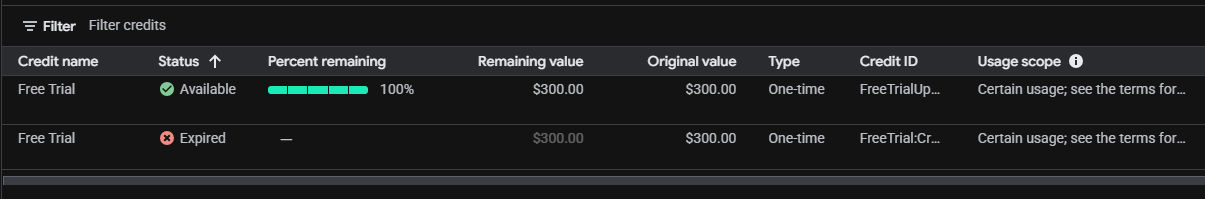

As you can see in the image. Google ended creating two free trial accounts one expired immediately and the other not until August. New API key's created, whether from the API service on Google Cloud or through Colab woul not work. I would get errors like below:


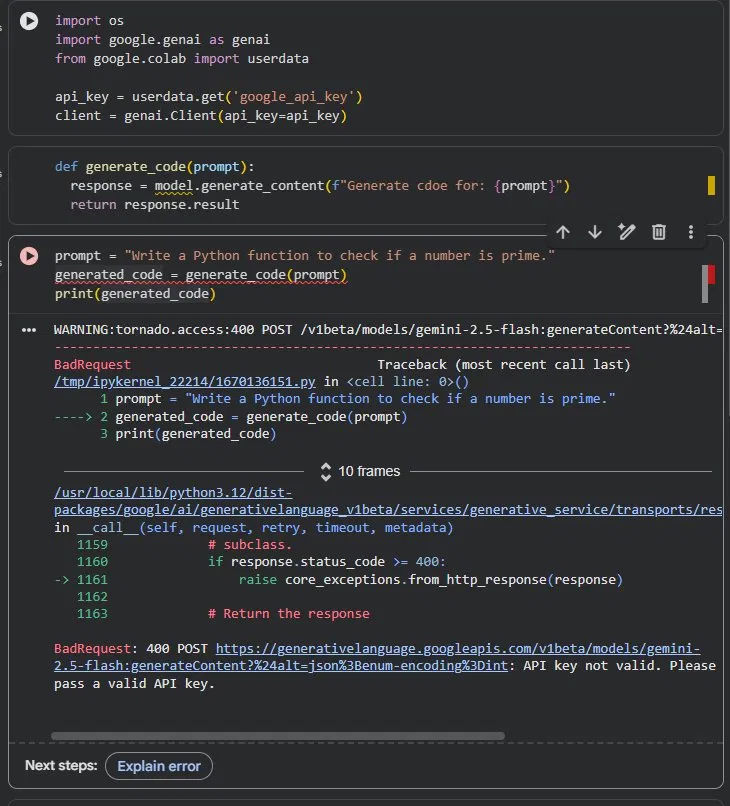


I probably spent three hours trying to figure out why and then ended up creating one with groq. Which of course means that I had to change some of the code sections to work with this new option.I had a great deal of un in this assignment. And will definitely be using htis in my life.

**Refrences**


1.   Lab 4.2 Build a Code-Generating AI Bot: R@R
2.   Using API keys (and other sensitive data) in a Colab notebook: https://medium.com/google-cloud/using-api-keys-and-other-sensitive-data-in-a-colab-notebook-c2feba57c4e0
3. Where / how to store API keys in Google Colabs securely? : https://stackoverflow.com/questions/61340526/where-how-to-store-api-keys-in-google-colabs-securely
4. API refrence groq: https://console.groq.com/docs/overview